In [24]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import kagglehub

import pandas as pd

In [ ]:

# Download latest version
data_path = kagglehub.dataset_download("zaraks/pascal-voc-2007")

print("Path to dataset files:", data_path)

Path to dataset files: /home/amir/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1


In [ ]:
PATH = Path(data_path)
paths = list(PATH.iterdir())
paths


[PosixPath('/home/amir/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/VOCtrainval_06-Nov-2007'),
 PosixPath('/home/amir/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/PASCAL_VOC'),
 PosixPath('/home/amir/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/voctest_06-nov-2007'),
 PosixPath('/home/amir/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/pascal_voc'),
 PosixPath('/home/amir/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/voctrainval_06-nov-2007'),
 PosixPath('/home/amir/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/VOCtest_06-Nov-2007')]

In [15]:
list((PATH / 'pascal_voc'/ 'PASCAL_VOC').iterdir())

[PosixPath('/home/amir/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/pascal_voc/PASCAL_VOC/pascal_val2007.json'),
 PosixPath('/home/amir/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/pascal_voc/PASCAL_VOC/pascal_val2012.json'),
 PosixPath('/home/amir/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/pascal_voc/PASCAL_VOC/pascal_train2012.json'),
 PosixPath('/home/amir/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/pascal_voc/PASCAL_VOC/pascal_train2007.json'),
 PosixPath('/home/amir/.cache/kagglehub/datasets/zaraks/pascal-voc-2007/versions/1/pascal_voc/PASCAL_VOC/pascal_test2007.json')]

In [ ]:
# Load the training annotations
train_json = json.load((PATH/'pascal_voc/PASCAL_VOC/pascal_train2007.json').open())
train_json.keys()

dict_keys(['images', 'type', 'annotations', 'categories'])

In [17]:
IMAGES, ANNOTATIONS, CATEGORIES = ['images', 'annotations', 'categories']
train_json[IMAGES][:5]

[{'file_name': '000012.jpg', 'height': 333, 'width': 500, 'id': 12},
 {'file_name': '000017.jpg', 'height': 364, 'width': 480, 'id': 17},
 {'file_name': '000023.jpg', 'height': 500, 'width': 334, 'id': 23},
 {'file_name': '000026.jpg', 'height': 333, 'width': 500, 'id': 26},
 {'file_name': '000032.jpg', 'height': 281, 'width': 500, 'id': 32}]

In [18]:
train_json[ANNOTATIONS][:5]

[{'segmentation': [[155, 96, 155, 270, 351, 270, 351, 96]],
  'area': 34104,
  'iscrowd': 0,
  'image_id': 12,
  'bbox': [155, 96, 196, 174],
  'category_id': 7,
  'id': 1,
  'ignore': 0},
 {'segmentation': [[184, 61, 184, 199, 279, 199, 279, 61]],
  'area': 13110,
  'iscrowd': 0,
  'image_id': 17,
  'bbox': [184, 61, 95, 138],
  'category_id': 15,
  'id': 2,
  'ignore': 0},
 {'segmentation': [[89, 77, 89, 336, 403, 336, 403, 77]],
  'area': 81326,
  'iscrowd': 0,
  'image_id': 17,
  'bbox': [89, 77, 314, 259],
  'category_id': 13,
  'id': 3,
  'ignore': 0},
 {'segmentation': [[8, 229, 8, 500, 245, 500, 245, 229]],
  'area': 64227,
  'iscrowd': 0,
  'image_id': 23,
  'bbox': [8, 229, 237, 271],
  'category_id': 2,
  'id': 4,
  'ignore': 0},
 {'segmentation': [[229, 219, 229, 500, 334, 500, 334, 219]],
  'area': 29505,
  'iscrowd': 0,
  'image_id': 23,
  'bbox': [229, 219, 105, 281],
  'category_id': 2,
  'id': 5,
  'ignore': 0}]

In [19]:
train_json[CATEGORIES][:5]

[{'supercategory': 'none', 'id': 1, 'name': 'aeroplane'},
 {'supercategory': 'none', 'id': 2, 'name': 'bicycle'},
 {'supercategory': 'none', 'id': 3, 'name': 'bird'},
 {'supercategory': 'none', 'id': 4, 'name': 'boat'},
 {'supercategory': 'none', 'id': 5, 'name': 'bottle'}]

In [ ]:
# Load the annotation and image info
IMAGES, ANNOTATIONS, CATEGORIES = ['images', 'annotations', 'categories']
images = {im['id']: im for im in train_json[IMAGES]}
categories = {cat['id']: cat['name'] for cat in train_json[CATEGORIES]}

# Build DataFrame rows
voc_rows = []
for ann in train_json[ANNOTATIONS]:
    image_id = ann['image_id']
    image_info = images[image_id]
    category_id = ann['category_id']
    label_name = categories[category_id]
    # VOC bbox: [x, y, width, height]
    x, y, w, h = ann['bbox']
    row = {
        'ImageID': image_info['file_name'].replace('.jpg', ''),  # match bus-truck style
        'LabelName': label_name,
        'XMin': x / image_info['width'],
        'XMax': (x + w) / image_info['width'],
        'YMin': y / image_info['height'],
        'YMax': (y + h) / image_info['height'],
    }
    voc_rows.append(row)

VOC_DF = pd.DataFrame(voc_rows)
display(VOC_DF.head())

,ImageID,LabelName,XMin,XMax,YMin,YMax
0,000012,car,0.310000,0.702000,0.288288,0.810811
1,000017,person,0.383333,0.581250,0.167582,0.546703
2,000017,horse,0.185417,0.839583,0.211538,0.923077
3,000023,bicycle,0.023952,0.733533,0.458000,1.000000
4,000023,bicycle,0.685629,1.000000,0.438000,1.000000


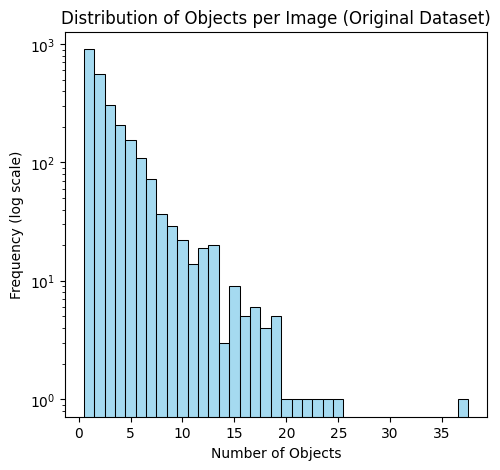

In [ ]:
# Count objects per image for the original dataset
original_object_counts = VOC_DF['ImageID'].value_counts()

# Define bins for the original dataset (0-5, 6-10, etc.)
max_original_objects = original_object_counts.max()
original_bins = np.arange(0, max_original_objects + 5, 5)

# Plot histograms
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(original_object_counts, bins=original_bins, kde=False, color='skyblue', discrete=True)
plt.title('Distribution of Objects per Image (Original Dataset)')
plt.xlabel('Number of Objects')
plt.ylabel('Frequency (log scale)')
plt.yscale('log')

In [23]:
# create a custom dataset
class OpenImages(Dataset):
    def __init__(self, df, image_folder = IMAGE_ROOT):
        self.df = df
        self.unique_images = df['ImageID'].unique()
        self.root = image_folder

    def __len__(self):
        return len(self.unique_images)

    def __getitem__(self, index):
        image_id = self.unique_images[index]
        image_path = f'{self.root}/images/{image_id}.jpg'
        image = cv2.imread(image_path, 1)  # converting to RGB
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        df = self.df.copy()
        df = df[df['ImageID'] == image_id]  # getting the row based on the index
        h, w, _ = image.shape
        boxes = df['XMin,YMin,XMax,YMax'.split(',')].values
        boxes = (boxes*np.array([w,h,w,h])).astype(np.uint16)
        classes = df['LabelName'].values.tolist()

        return image, boxes, classes, image_path

NameError: name 'Dataset' is not defined